<a href="https://colab.research.google.com/github/Navyasree-ulava/ML-Lab/blob/main/Lab4_AP23110011581.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2 align="center"> Logistic Regression </h2>

### Task 2: Load the Data and Libraries
---

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use("ggplot")
%matplotlib inline

In [6]:
from pylab import rcParams
rcParams['figure.figsize'] = 12, 8
data=pd.read_csv("DMV_Written_Tests.csv")
print(data.head())

X = data[["DMV_Test_1", "DMV_Test_2"]].values
y = data["Results"].values

   DMV_Test_1  DMV_Test_2  Results
0   34.623660   78.024693        0
1   30.286711   43.894998        0
2   35.847409   72.902198        0
3   60.182599   86.308552        1
4   79.032736   75.344376        1


### Task 3: Visualize the Data
---

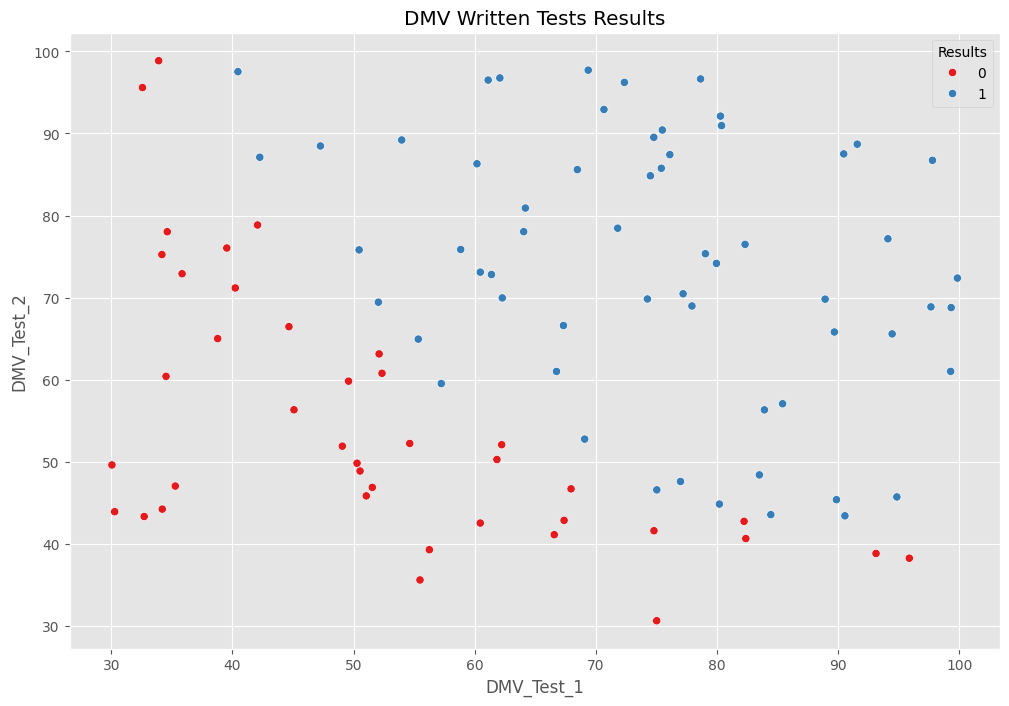

In [8]:
sns.scatterplot(x="DMV_Test_1", y="DMV_Test_2", hue="Results", data=data, palette="Set1")
plt.title("DMV Written Tests Results")
plt.show()


### Task 4: Define the Logistic Sigmoid Function $\sigma(z)$
---

$$ \sigma(z) = \frac{1}{1+e^{-z}}$$

In [9]:
# Task 4: Define the Logistic Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test
print("Sigmoid(0) =", sigmoid(0))


Sigmoid(0) = 0.5


### Task 5: Compute the Cost Function $J(\theta)$ and Gradient
---

The objective of logistic regression is to minimize the cost function

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [ y^{(i)}log(h_{\theta}(x^{(i)})) + (1 - y^{(i)})log(1 - (h_{\theta}(x^{(i)}))]$$

where the gradient of the cost function is given by

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_{\theta}(x^{(i)}) - y^{(i)})x_j^{(i)}$$

In [10]:
# Task 5: Compute the Cost Function J(θ) and Gradient
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    epsilon = 1e-5  # to avoid log(0)
    cost = (-1/m) * (y.dot(np.log(h+epsilon)) + (1-y).dot(np.log(1-h+epsilon)))
    return cost

def compute_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(X.dot(theta))
    gradient = (1/m) * X.T.dot(h - y)
    return gradient


### Task 6: Cost and Gradient at Initialization
---

In [11]:
# Task 6: Cost and Gradient at Initialization
m, n = X.shape
X_bias = np.hstack([np.ones((m,1)), X])  # Add bias term (x0=1)
theta = np.zeros(n+1)

initial_cost = compute_cost(X_bias, y, theta)
initial_grad = compute_gradient(X_bias, y, theta)

print("Initial Cost:", initial_cost)
print("Initial Gradient:", initial_grad)


Initial Cost: 0.6931271807599428
Initial Gradient: [ -0.1        -12.00921659 -11.26284221]


### Task 7: Gradient Descent
---

Minimize the cost function $J(\theta)$ by updating the below equation and repeat until convergence
$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$ (simultaneously update $\theta_j$ for all $j$)

In [12]:
# Task 7: Gradient Descent
def gradient_descent(X, y, theta, alpha, iterations):
    costs = []
    for i in range(iterations):
        grad = compute_gradient(X, y, theta)
        theta = theta - alpha * grad
        cost = compute_cost(X, y, theta)
        costs.append(cost)
    return theta, costs

# Run gradient descent
alpha = 0.001
iterations = 100000
theta_opt, costs = gradient_descent(X_bias, y, theta, alpha, iterations)

print("Optimized Theta:", theta_opt)


Optimized Theta: [-4.81180027  0.04528064  0.03819149]


### Task 8: Plotting the Convergence of $J(\theta)$
---

Plot $J(\theta)$ against the number of iterations of gradient descent:

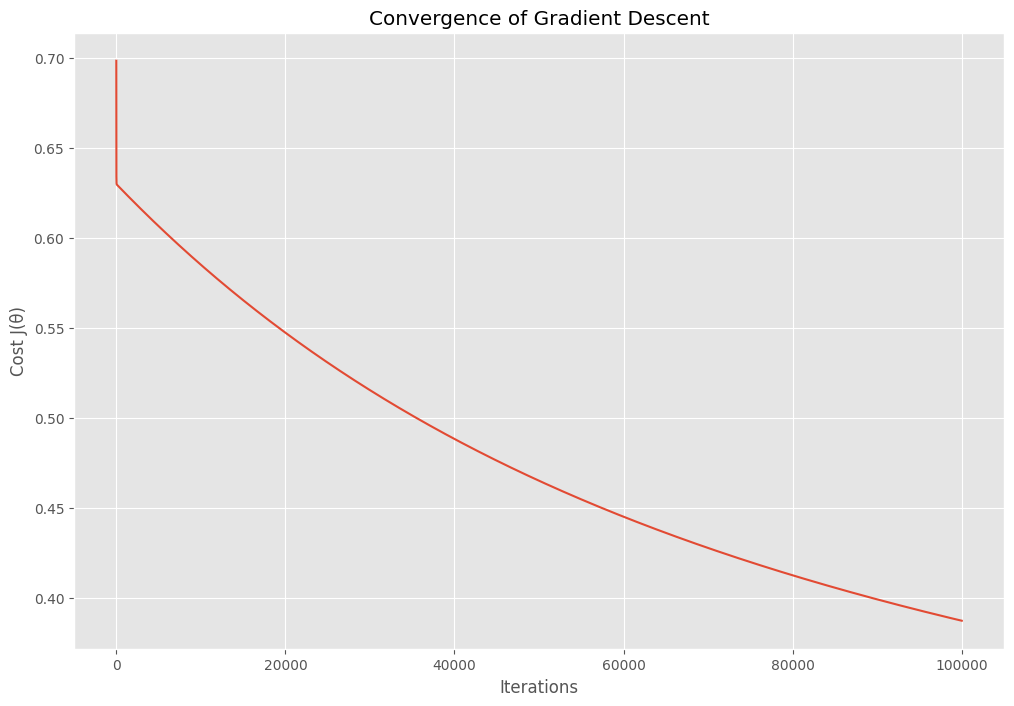

In [13]:
# Task 8: Plot convergence
plt.plot(range(len(costs)), costs)
plt.xlabel("Iterations")
plt.ylabel("Cost J(θ)")
plt.title("Convergence of Gradient Descent")
plt.show()


### Task 9: Plotting the decision boundary
---

$h_\theta(x) = \sigma(z)$, where $\sigma$ is the logistic sigmoid function and $z = \theta^Tx$

When $h_\theta(x) \geq 0.5$ the model predicts class "1":

$\implies \sigma(\theta^Tx) \geq 0.5$

$\implies \theta^Tx \geq 0$ predict class "1"

Hence, $\theta_1 + \theta_2x_2 + \theta_3x_3 = 0$ is the equation for the decision boundary, giving us

$ x_3 = \frac{-(\theta_1+\theta_2x_2)}{\theta_3}$

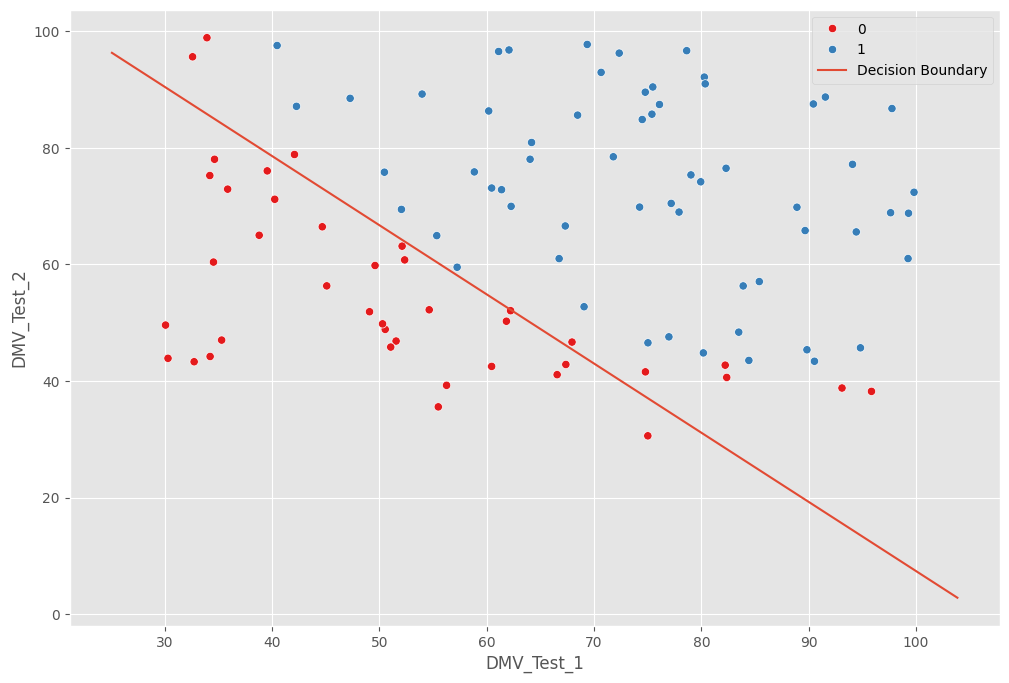

In [14]:
# Task 9: Plot Decision Boundary
sns.scatterplot(x="DMV_Test_1", y="DMV_Test_2", hue="Results", data=data, palette="Set1")

x_values = [np.min(X[:,0]-5), np.max(X[:,1]+5)]
y_values = -(theta_opt[0] + np.dot(theta_opt[1], x_values)) / theta_opt[2]
plt.plot(x_values, y_values, label="Decision Boundary")
plt.legend()
plt.show()


### Task 10: Predictions using the optimized $\theta$ values
---

$h_\theta(x) = x\theta$

In [15]:
# Task 10: Predictions
def predict(X, theta):
    probability = sigmoid(X.dot(theta))
    return [1 if p >= 0.5 else 0 for p in probability]

# Prediction accuracy
y_pred = predict(X_bias, theta_opt)
accuracy = np.mean(y_pred == y) * 100
print("Training Accuracy:", accuracy, "%")

# Example: Predict if student with (DMV_Test_1=45, DMV_Test_2=85) will pass
test_student = np.array([1, 45, 85])  # add bias
probability = sigmoid(test_student.dot(theta_opt))
print("Probability of Passing:", probability)
print("Prediction:", "Pass" if probability >= 0.5 else "Fail")


Training Accuracy: 91.0 %
Probability of Passing: 0.6158819967649669
Prediction: Pass
